# **Self-Sufficiency navigator**
## *Notebook 1. Data Loading*
Four datasets:

1. SSS 2023 Excel file (direct load from University of Washington ) - Self-Sufficiency Numbers

2. IPUMS census microdata (from computer) - to make model to predic earnings

3. Bureau of labor requests.post(BLS_API, CPI_series) - JSON from BLS API - inflation

4.  requests.post(BLS_API, Wage_series) - JSON from BLS API - wage change

In [42]:
#pip install pandas requests

In [43]:
import pandas as pd

In [44]:
#pip install openpyxl

In [45]:
# all nessesary libraries
import pandas as pd
import urllib.request
import requests
import json

In [46]:
# loading a dataset for Self-suficient income for 700+ family models in Maryland
url="https://selfsufficiencystandard.org/wp-content/uploads/2023/04/MD2023_SSS.xlsx"
urllib.request.urlretrieve(url,"MD2023_SSS.xlsx")

('MD2023_SSS.xlsx', <http.client.HTTPMessage at 0x293765f2450>)

In [47]:
# loading SSS excel file to pandas
df_sss=pd.read_excel("MD2023_SSS.xlsx",sheet_name="By Family")

In [48]:
df_sss.shape

(17256, 26)

In [49]:
df_sss.info()

<class 'pandas.DataFrame'>
RangeIndex: 17256 entries, 0 to 17255
Data columns (total 26 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Family Type                                               17256 non-null  str    
 1   Adult(s)                                                  17256 non-null  int64  
 2   Infant(s)                                                 17256 non-null  int64  
 3   Preschooler(s)                                            15120 non-null  float64
 4   Schoolager(s)                                             15120 non-null  float64
 5   Teenager(s)                                               15120 non-null  float64
 6   State                                                     17256 non-null  str    
 7   Year                                                      17256 non-null  int64  
 8   All Families Table #       

In [50]:
df_sss.head()

,Family Type,Adult(s),Infant(s),Preschooler(s),Schoolager(s),Teenager(s),State,Year,All Families Table #,County,...,Broadband & Cell Phone,Other Necessities,Taxes,Earned Income Tax Credit (-),Child Care Tax Credit (-),Child Tax Credit (-),Hourly Self-Sufficiency Wage,Monthly Self-Sufficiency Wage,Annual Self-Sufficiency Wage,Emergency Savings
0,a1i0p0s0t0,1,0,0.0,0.0,0.0,MD,2023,1,Allegany County,...,111.15,163.22,575.25,0.00,0.0,0.00,14.10,2481.87,29782.44,67.27
1,a1i1p0s0t0,1,1,0.0,0.0,0.0,MD,2023,1,Allegany County,...,111.15,335.93,1146.51,0.00,-50.0,-166.67,26.91,4736.24,56834.88,226.76
2,a1i0p1s0t0,1,0,1.0,0.0,0.0,MD,2023,1,Allegany County,...,111.15,323.20,1083.84,0.00,-50.0,-166.67,25.76,4533.52,54402.21,210.51
3,a1i0p0s1t0,1,0,0.0,1.0,0.0,MD,2023,1,Allegany County,...,111.15,301.92,979.04,0.00,-50.0,-166.67,23.83,4194.69,50336.27,183.35
4,a1i0p0s0t1,1,0,0.0,0.0,1.0,MD,2023,1,Allegany County,...,111.15,255.53,690.27,-82.62,0.0,-166.67,19.11,3363.00,40355.98,126.18


In [51]:
df_sss.columns.tolist()

['Family Type',
 'Adult(s)',
 'Infant(s)',
 'Preschooler(s)',
 'Schoolager(s)',
 'Teenager(s)',
 'State ',
 'Year',
 'All Families Table #',
 'County',
 'Housing Costs',
 'Child Care Costs',
 'Food Costs ',
 'Transportation Costs',
 'Health Care Costs ',
 'Miscellaneous costs',
 'Broadband & Cell Phone',
 'Other Necessities',
 'Taxes',
 'Earned Income Tax Credit (-)',
 'Child Care Tax Credit (-)',
 'Child Tax Credit (-)',
 'Hourly Self-Sufficiency Wage                           ',
 'Monthly Self-Sufficiency Wage                           ',
 'Annual Self-Sufficiency Wage                           ',
 'Emergency Savings']

In [52]:
df_sss.describe()

,Adult(s),Infant(s),Preschooler(s),Schoolager(s),Teenager(s),Year,All Families Table #,Housing Costs,Child Care Costs,Food Costs,...,Broadband & Cell Phone,Other Necessities,Taxes,Earned Income Tax Credit (-),Child Care Tax Credit (-),Child Tax Credit (-),Hourly Self-Sufficiency Wage,Monthly Self-Sufficiency Wage,Annual Self-Sufficiency Wage,Emergency Savings
count,17256.000000,17256.000000,15120.000000,15120.000000,15120.000000,17256.0,17256.000000,17256.000000,17256.000000,17256.000000,...,17256.000000,17256.000000,17256.000000,17256.000000,17256.000000,17256.000000,17256.000000,17256.000000,17256.000000,17256.000000
mean,2.535466,1.728790,1.200000,1.200000,1.200000,2023.0,12.500000,2118.165394,3446.721779,1722.791143,...,179.069388,890.118642,4195.754820,-0.130342,-94.972966,-846.488234,47.637963,13224.538769,158694.464254,627.729584
std,1.847822,2.188703,1.326694,1.326694,1.326694,0.0,6.922387,613.836721,1945.052343,661.784799,...,81.737581,271.268251,1983.068954,4.475379,20.491672,296.651264,21.952330,4759.756755,57117.080689,401.808942
min,1.000000,0.000000,0.000000,0.000000,0.000000,2023.0,1.000000,669.900000,0.000000,309.330000,...,111.150000,163.220000,456.820000,-282.450000,-100.000000,-2000.000000,11.500000,2481.870000,29782.440000,55.820000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2023.0,6.750000,1678.000000,2031.140000,1332.790000,...,111.150000,703.697500,2732.782500,0.000000,-100.000000,-1000.000000,32.030000,9815.480000,117785.740000,362.507500
50%,2.000000,1.000000,1.000000,1.000000,1.000000,2023.0,12.500000,2048.320000,3316.250000,1604.765000,...,155.380000,860.145000,3834.920000,0.000000,-100.000000,-875.000000,42.215000,12495.615000,149947.375000,518.215000
75%,3.000000,2.000000,2.000000,2.000000,2.000000,2023.0,18.250000,2472.190000,4671.120000,1924.245000,...,199.620000,1042.770000,5210.167500,0.000000,-100.000000,-666.670000,57.940000,15797.662500,189571.930000,806.355000
max,10.000000,10.000000,6.000000,6.000000,6.000000,2023.0,24.000000,5478.940000,10945.330000,5927.740000,...,509.260000,2464.680000,18340.560000,0.000000,0.000000,0.000000,178.280000,43861.240000,526334.930000,2893.540000


In [53]:
df_sss.isnull().sum()

Family Type                                                    0
Adult(s)                                                       0
Infant(s)                                                      0
Preschooler(s)                                              2136
Schoolager(s)                                               2136
Teenager(s)                                                 2136
State                                                          0
Year                                                           0
All Families Table #                                           0
County                                                         0
Housing Costs                                                  0
Child Care Costs                                               0
Food Costs                                                     0
Transportation Costs                                           0
Health Care Costs                                              0
Miscellaneous costs      

## DATA 2: IPUMS Data Ingestion

In [54]:
df_ipums = pd.read_csv("usa_00002.csv.gz")

In [55]:
# What variables are in the original IPUMS extract?
print(f"Total columns: {len(df_ipums.columns)}")
print(f"\nAll columns in extract (alphabetical):")
for col in sorted(df_ipums.columns):
    print(f"  {col}")

# Check specifically for the immigration variables we want
target_vars = ["CITIZEN", "SPEAKENG", "YRIMMIG", "BPL", "NATIVITY", "LANGUAGE"]
print(f"\n--- Immigration-related variables ---")
for var in target_vars:
    status = "✅ present" if var in df_ipums.columns else "❌ missing"
    print(f"  {var}: {status}")

Total columns: 63

All columns in extract (alphabetical):
  AGE
  BPL
  BPLD
  CBSERIAL
  CITIZEN
  CITY
  CLASSWKR
  CLASSWKRD
  CLUSTER
  DEGFIELD
  DEGFIELDD
  EDUC
  EDUCD
  ELDCH
  EMPSTAT
  EMPSTATD
  FAMSIZE
  FTOTINC
  GQ
  GRADEATT
  GRADEATTD
  HHWT
  HISPAN
  HISPAND
  INCEARN
  INCTOT
  INCWAGE
  IND
  LABFORCE
  LANGUAGE
  LANGUAGED
  LOOKING
  MARRNO
  MARST
  METAREA
  METAREAD
  METRO
  NCHILD
  NCHLT5
  OCC
  OCCSOC
  PERNUM
  PERWT
  POVERTY
  PUMA
  PWSTATE2
  RACE
  RACED
  RELATE
  RELATED
  SAMPLE
  SERIAL
  SEX
  SPEAKENG
  STATEFIP
  STRATA
  UHRSWORK
  WKSWORK2
  YEAR
  YNGCH
  YRIMMIG
  YRSUSA1
  YRSUSA2

--- Immigration-related variables ---
  CITIZEN: ✅ present
  SPEAKENG: ✅ present
  YRIMMIG: ✅ present
  BPL: ✅ present
  NATIVITY: ❌ missing
  LANGUAGE: ✅ present


In [56]:
# Check specifically for the immigration variables we want
target_vars = ["CITIZEN", "SPEAKENG", "YRIMMIG", "BPL", "NATIVITY", "LANGUAGE"]
print(f"\n--- Immigration-related variables ---")
for var in target_vars:
    status = "✅ present" if var in df_ipums.columns else "❌ missing"
    print(f"  {var}: {status}")


--- Immigration-related variables ---
  CITIZEN: ✅ present
  SPEAKENG: ✅ present
  YRIMMIG: ✅ present
  BPL: ✅ present
  NATIVITY: ❌ missing
  LANGUAGE: ✅ present


In [57]:
df_ipums[df_ipums["YEAR"] == 2023]

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEFIP,PUMA,METRO,METAREA,...,IND,WKSWORK2,UHRSWORK,LOOKING,INCTOT,FTOTINC,INCWAGE,INCEARN,POVERTY,PWSTATE2
7217658,2023,202301,3,2.023010e+12,47.0,2023000000031,1,402.0,4,NaN,...,0,0,0,3,0,9999999,0,0,0,0
7217659,2023,202301,5,2.023010e+12,57.0,2023000000051,1,2802.0,4,NaN,...,4971,2,28,1,2500,9999999,2500,2500,0,0
7217660,2023,202301,6,2.023010e+12,52.0,2023000000061,1,1202.0,4,NaN,...,7860,1,30,1,500,9999999,500,500,0,0
7217661,2023,202301,7,2.023010e+12,43.0,2023000000071,1,1801.0,4,NaN,...,3570,0,0,3,0,9999999,0,0,0,0
7217662,2023,202301,10,2.023010e+12,41.0,2023000000101,1,2802.0,4,NaN,...,7870,2,10,3,3700,9999999,3700,3700,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8762381,2023,202301,1519005,2.023001e+12,352.0,2023015190051,56,100.0,1,NaN,...,7290,2,40,3,17000,44100,17000,17000,189,0
8762382,2023,202301,1519006,2.023001e+12,45.0,2023015190061,56,400.0,2,NaN,...,7860,6,40,3,22000,109400,22000,22000,468,56
8762383,2023,202301,1519007,2.023001e+12,125.0,2023015190071,56,500.0,1,NaN,...,8680,6,35,3,13400,13400,13400,13400,86,56
8762384,2023,202301,1519007,2.023001e+12,125.0,2023015190071,56,500.0,1,NaN,...,9480,1,40,3,6000,6000,6000,6000,39,56


In [58]:
print("Shape:", df_ipums.shape)

display(df_ipums.head())

df_ipums.info()

Shape: (10312455, 63)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEFIP,PUMA,METRO,METAREA,...,IND,WKSWORK2,UHRSWORK,LOOKING,INCTOT,FTOTINC,INCWAGE,INCEARN,POVERTY,PWSTATE2
0,2000,200007,1,NaN,110.0,2000000000017,1,NaN,2,0.0,...,819,6,45,0,45800,70100,47300,47300,501,1
1,2000,200007,1,NaN,110.0,2000000000017,1,NaN,2,0.0,...,819,3,32,0,24300,70100,24300,24300,501,1
2,2000,200007,2,NaN,31.0,2000000000027,1,NaN,2,0.0,...,77,6,40,3,-10000,12000,0,-10000,92,0
3,2000,200007,2,NaN,31.0,2000000000027,1,NaN,2,0.0,...,497,6,40,0,22000,12000,22000,22000,92,1
4,2000,200007,2,NaN,31.0,2000000000027,1,NaN,2,0.0,...,868,0,0,0,0,12000,0,0,92,1


<class 'pandas.DataFrame'>
RangeIndex: 10312455 entries, 0 to 10312454
Data columns (total 63 columns):
 #   Column     Dtype  
---  ------     -----  
 0   YEAR       int64  
 1   SAMPLE     int64  
 2   SERIAL     int64  
 3   CBSERIAL   float64
 4   HHWT       float64
 5   CLUSTER    int64  
 6   STATEFIP   int64  
 7   PUMA       float64
 8   METRO      int64  
 9   METAREA    float64
 10  METAREAD   float64
 11  CITY       int64  
 12  STRATA     float64
 13  GQ         int64  
 14  PERNUM     int64  
 15  PERWT      float64
 16  FAMSIZE    int64  
 17  NCHILD     int64  
 18  NCHLT5     int64  
 19  ELDCH      int64  
 20  YNGCH      int64  
 21  RELATE     int64  
 22  RELATED    int64  
 23  SEX        int64  
 24  AGE        int64  
 25  MARST      int64  
 26  MARRNO     float64
 27  RACE       int64  
 28  RACED      int64  
 29  HISPAN     int64  
 30  HISPAND    int64  
 31  BPL        int64  
 32  BPLD       int64  
 33  CITIZEN    int64  
 34  YRIMMIG    int64  
 35  YRS

In [59]:
df_ipums.columns.tolist()

['YEAR',
 'SAMPLE',
 'SERIAL',
 'CBSERIAL',
 'HHWT',
 'CLUSTER',
 'STATEFIP',
 'PUMA',
 'METRO',
 'METAREA',
 'METAREAD',
 'CITY',
 'STRATA',
 'GQ',
 'PERNUM',
 'PERWT',
 'FAMSIZE',
 'NCHILD',
 'NCHLT5',
 'ELDCH',
 'YNGCH',
 'RELATE',
 'RELATED',
 'SEX',
 'AGE',
 'MARST',
 'MARRNO',
 'RACE',
 'RACED',
 'HISPAN',
 'HISPAND',
 'BPL',
 'BPLD',
 'CITIZEN',
 'YRIMMIG',
 'YRSUSA1',
 'YRSUSA2',
 'LANGUAGE',
 'LANGUAGED',
 'SPEAKENG',
 'EDUC',
 'EDUCD',
 'GRADEATT',
 'GRADEATTD',
 'DEGFIELD',
 'DEGFIELDD',
 'EMPSTAT',
 'EMPSTATD',
 'LABFORCE',
 'CLASSWKR',
 'CLASSWKRD',
 'OCC',
 'OCCSOC',
 'IND',
 'WKSWORK2',
 'UHRSWORK',
 'LOOKING',
 'INCTOT',
 'FTOTINC',
 'INCWAGE',
 'INCEARN',
 'POVERTY',
 'PWSTATE2']

ncome distribution (FTOTINC)

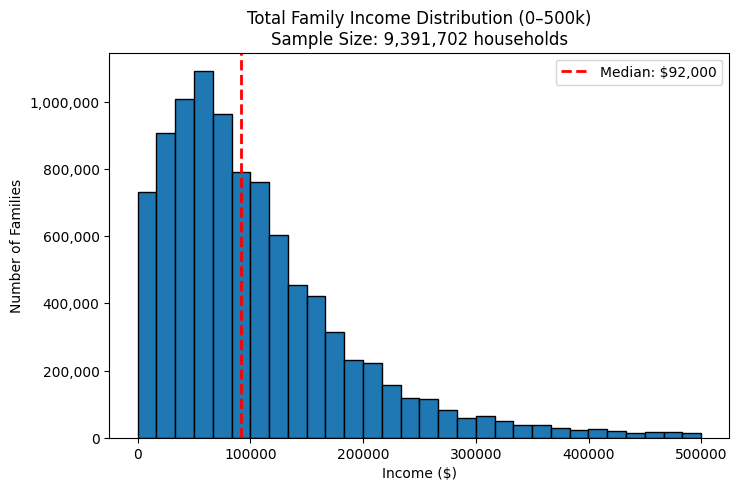

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# full data for median
full_income = df_ipums["FTOTINC"]
full_income = full_income[full_income >= 0]

median_income = np.median(full_income)

# filtered for visualization
income = full_income[full_income < 500000]

plt.figure(figsize=(8,5))

plt.hist(income, bins=30, edgecolor='black')

plt.axvline(median_income, color='red', linestyle='dashed', linewidth=2,
            label=f"Median: ${median_income:,.0f}")
n = len(income)
plt.title(f"Total Family Income Distribution (0–500k)\nSample Size: {n:,} households")
plt.xlabel("Income ($)")
plt.ylabel("Number of Families")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.legend()

plt.show()

In [61]:
df_md = df_ipums[df_ipums["STATEFIP"] == 24]

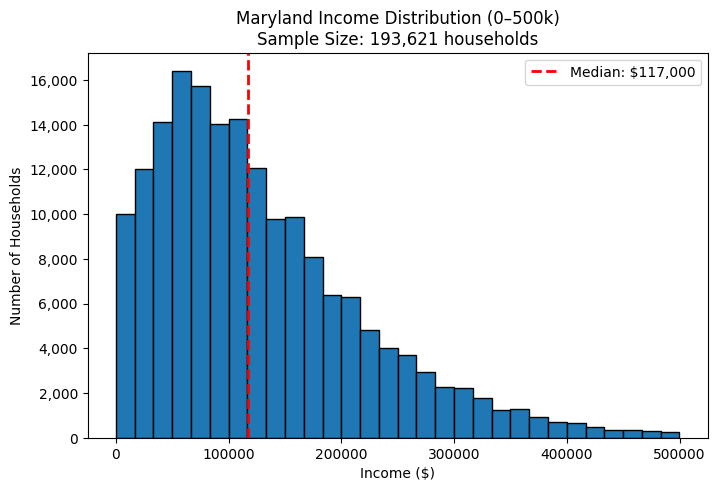

In [62]:
income_md = df_md["FTOTINC"]
income_md = income_md[income_md >= 0]

median_md = np.median(income_md)
n_md = len(income_md)

income_md_vis = income_md[income_md < 500000]

plt.figure(figsize=(8,5))

plt.hist(income_md_vis, bins=30, edgecolor='black')

plt.axvline(median_md, color='red', linestyle='dashed', linewidth=2,
            label=f"Median: ${median_md:,.0f}")

plt.title(f"Maryland Income Distribution (0–500k)\nSample Size: {n_md:,} households")
plt.xlabel("Income ($)")
plt.ylabel("Number of Households")

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.show()

In [63]:
n = len(df_ipums)
print(n)

10312455


In [64]:
df_sss.columns = df_sss.columns.str.strip()

In [65]:
cost = df_sss["Annual Self-Sufficiency Wage"]

In [66]:
df_sss["County"].unique()

<ArrowStringArray>
[       'Allegany County',    'Anne Arundel County',       'Baltimore County',
         'Calvert County',        'Caroline County',         'Carroll County',
           'Cecil County',         'Charles County',      'Dorchester County',
       'Frederick County',         'Garrett County',         'Harford County',
          'Howard County',            'Kent County',      'Montgomery County',
 'Prince George's County',    'Queen Anne's County',      'St. Mary's County',
        'Somerset County',          'Talbot County',      'Washington County',
        'Wicomico County',       'Worcester County',         'Baltimore city']
Length: 24, dtype: str

In [67]:
df_moco = df_sss[df_sss["County"] == "Montgomery County"]

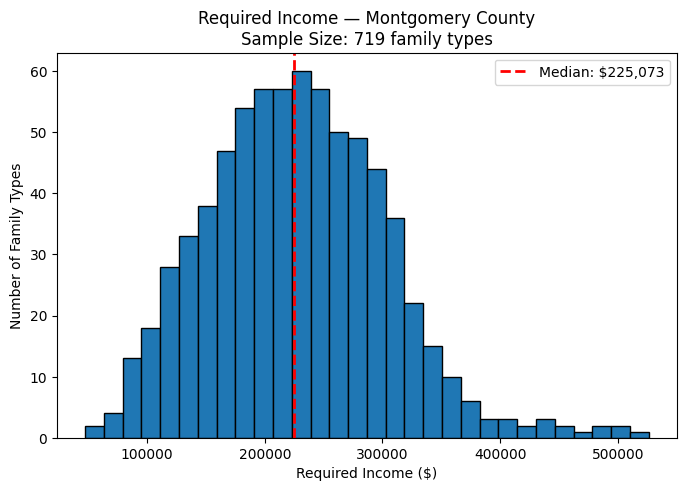

In [68]:
cost_moco = df_moco["Annual Self-Sufficiency Wage"]
cost_moco = cost_moco[cost_moco > 0]

median_moco = np.median(cost_moco)
n_moco = len(cost_moco)

plt.figure(figsize=(8,5))
plt.hist(cost_moco, bins=30, edgecolor='black')

plt.axvline(median_moco, color='red', linestyle='dashed', linewidth=2,
            label=f"Median: ${median_moco:,.0f}")

plt.title(f"Required Income — Montgomery County\nSample Size: {n_moco:,} family types")
plt.xlabel("Required Income ($)")
plt.ylabel("Number of Family Types")

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.show()

In [69]:
df_ipums["YEAR"].unique()

array([2000, 2019, 2020, 2021, 2022, 2023, 2024])

In [70]:
df_ipums_2023 = df_ipums[df_ipums["YEAR"] == 2023]

In [71]:
df_md = df_ipums_2023[df_ipums_2023["STATEFIP"] == 24]

In [72]:

import pyarrow
# Filter to 2023, Maryland, working-age
df_md_2023 = df_ipums[
    (df_ipums["YEAR"] == 2023) &
    (df_ipums["STATEFIP"] == 24) &
    (df_ipums["AGE"] >= 18) &
    (df_ipums["AGE"] <= 64)
].copy()

# Drop INCEARN missing codes
df_md_2023 = df_md_2023[~df_md_2023["INCEARN"].isin([9999999, 9999998])]

# Check the shape
print(df_md_2023.shape)
print(df_md_2023["INCEARN"].describe())



(28077, 63)
count     28077.000000
mean      64966.348542
std       81316.668923
min       -8600.000000
25%       10000.000000
50%       46900.000000
75%       90000.000000
max      968000.000000
Name: INCEARN, dtype: float64


In [73]:
df_md_2023 = df_md_2023[df_md_2023["INCTOT"] <= 250000]

##  Add Immigration Features

Create FOREIGN_BORN as a binary indicator from BPL (per IPUMS docs:
BPL ≥ 100 means born outside the US). The other three immigration
variables (CITIZEN, SPEAKENG, YRSUSA1) are already in the dataset.

In [74]:
# Check the variables we're actually going to use
for var in ["BPL", "CITIZEN", "SPEAKENG", "YRSUSA1", "YRSUSA2", "YRIMMIG"]:
    print(f"\n=== {var} ===")
    print(df_md_2023[var].value_counts(dropna=False).head(10))


=== BPL ===
BPL
24     11511
11      1827
210     1122
42      1057
36      1018
600     1011
51       798
521      639
34       584
6        557
Name: count, dtype: int64

=== CITIZEN ===
CITIZEN
0    21595
2     2820
3     2542
1      406
Name: count, dtype: int64

=== SPEAKENG ===
SPEAKENG
3    21126
4     4112
5     1197
6      693
1      235
Name: count, dtype: int64

=== YRSUSA1 ===
YRSUSA1
0     21590
23      270
17      220
22      220
1       214
19      214
7       212
8       205
18      202
21      194
Name: count, dtype: int64

=== YRSUSA2 ===
YRSUSA2
0    21470
5     2244
4      986
2      958
1      933
3      772
Name: count, dtype: int64

=== YRIMMIG ===
YRIMMIG
0       21470
2000      270
2006      220
2001      220
2022      214
2004      214
2016      212
2015      205
2005      202
2002      194
Name: count, dtype: int64


In [75]:
# Create FOREIGN_BORN from BPL
df_md_2023["FOREIGN_BORN"] = (df_md_2023["BPL"] >= 100).astype(int)

# Quick sanity check
print("FOREIGN_BORN distribution:")
print(df_md_2023["FOREIGN_BORN"].value_counts())
print(f"\nForeign-born share: {df_md_2023['FOREIGN_BORN'].mean():.1%}")

FOREIGN_BORN distribution:
FOREIGN_BORN
0    21470
1     5893
Name: count, dtype: int64

Foreign-born share: 21.5%


In [76]:
df_md_2023.to_csv("ipums_md_2023.csv", index=False)

In [77]:
import os
print(os.path.getsize("ipums_md_2023.csv") / 1024 / 1024, "MB")

6.268084526062012 MB


## 4. Feature Selection

Goal: predict INCTOT using only features a Streamlit app user could answer about themselves.

**Excluded** (target leakage — derived from or part of income):
- INCWAGE, INCEARN, FTOTINC, POVERTY

**Excluded** (administrative or sample identifiers, not predictive):
- YEAR, SAMPLE, SERIAL, CBSERIAL, HHWT, CLUSTER, STRATA, GQ, PERNUM, PERWT

**Excluded** (redundant detailed versions — keeping the general versions):
- RELATED, RACED, HISPAND, BPLD, LANGUAGED, EDUCD, GRADEATTD, DEGFIELDD, EMPSTATD, CLASSWKRD, OCCSOC, METAREAD

**Excluded** (constant or near-constant after filtering):
- STATEFIP (always 24), AGE bounds already applied

**Selected features** (15):
- Demographics: AGE, SEX, RACE, HISPAN, MARST
- Family context: FAMSIZE, NCHILD, NCHLT5
- Education: EDUC, DEGFIELD
- Work: OCC, IND, CLASSWKR, UHRSWORK, WKSWORK2
- Geography: PUMA

In [78]:
target = "INCTOT"

features = [
    # Demographics
    "AGE", "SEX", "RACE", "HISPAN", "MARST",
    # Family context
    "FAMSIZE", "NCHILD", "NCHLT5",
    # Education
    "EDUC", "DEGFIELD",
    # Work
    "OCC", "IND", "CLASSWKR", "UHRSWORK", "WKSWORK2",
    # Geography
    "PUMA",
    # Immigration (new in v2)
    "FOREIGN_BORN", "CITIZEN", "SPEAKENG", "YRSUSA1",
]

import numpy as np

X = df_md_2023[features].copy()
y_raw = df_md_2023[target].copy()
y_clipped = y_raw.clip(lower=0)
y = np.log1p(y_clipped)

In [79]:
# Document the improvement
print("=== Model v2 Performance ===")
print(f"Features:              {len(features)}")
print(f"R² (test):             {r2:.3f}")
print(f"MAE:                   ${mae:,.0f}")
print(f"RMSE:                  ${rmse:,.0f}")
print(f"\nFor comparison, v1 baseline:")
print(f"R² (test):             0.492")
print(f"MAE:                   $29,228")
print(f"RMSE:                  $62,014")
print(f"\nR² improvement:        {(r2 - 0.492):+.3f}")

=== Model v2 Performance ===
Features:              20


NameError: name 'r2' is not defined

## 5. Train/Test Split

We split the data 80/20: 80% to train the model, 20% held out to evaluate honestly.
The held-out 20% never touches training, that's how we know the model generalizes
to people it has never seen, not just memorizes the training data.

`random_state=42` makes the split reproducible, same split every time you run this.

In [ ]:
#pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")

Training set: 21,890 rows
Test set:     5,473 rows


## 6. Train the XGBoost Model

XGBoost is a gradient-boosted decision tree algorithm. It builds many small trees,
each correcting the errors of the previous ones. It handles missing values
automatically and works well with mixed numeric and categorical (encoded) features.

Why XGBoost over linear regression? Income relationships are non-linear and full of
interactions (e.g., the effect of education depends on hours worked, occupation, age).
Trees handle these naturally; linear models would need manual feature engineering.

In [ ]:
# Install if not already installed
#!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,        # number of trees
    max_depth=6,             # how deep each tree can grow
    learning_rate=0.1,       # how much each tree adjusts predictions
    random_state=42,
    n_jobs=-1,               # use all CPU cores
    enable_categorical=False # all features are numeric (IPUMS uses code numbers)
)

# Train
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


## 7. Model Evaluation

Three standard regression metrics:
- **MAE** (Mean Absolute Error): average dollars off, on average
- **RMSE** (Root Mean Squared Error): penalizes big misses more than small ones
- **R²** (R-squared): fraction of income variance explained, 0 to 1

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict in log-space
y_pred_log = model.predict(X_test)

# Transform predictions AND test set back to dollars
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test)

# Compute metrics on real dollars
mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
r2  = r2_score(y_test_dollars, y_pred_dollars)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"Root Mean Squared Err: ${rmse:,.0f}")
print(f"R-squared:           {r2:.3f}")

Mean Absolute Error: $19,622
Root Mean Squared Err: $32,673
R-squared:           0.615


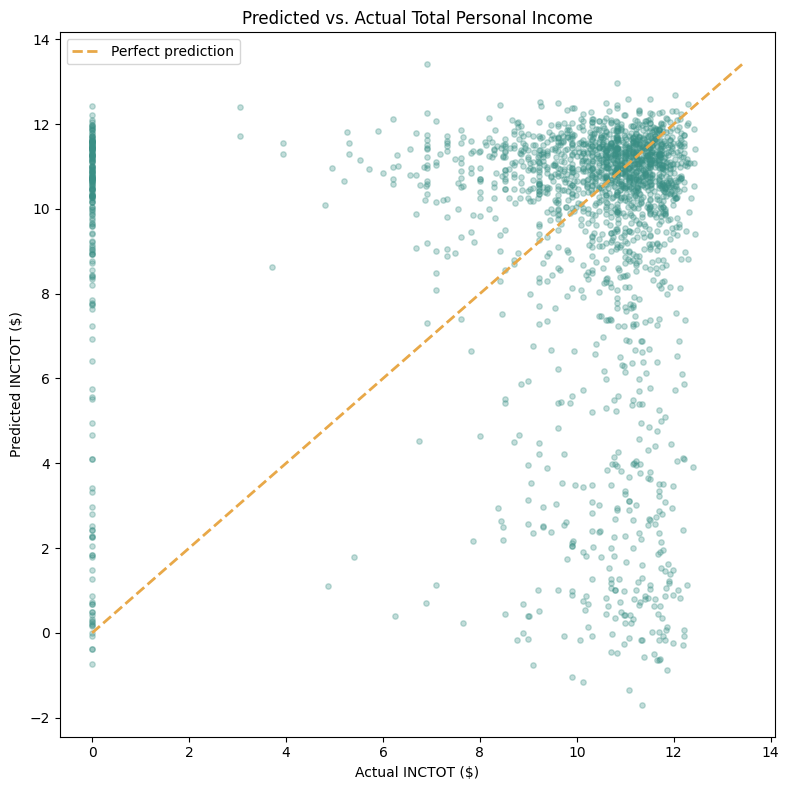

In [ ]:
# Predicted vs. actual scatter — diagonal line means perfect prediction
fig, ax = plt.subplots(figsize=(8, 8))
sample = np.random.choice(len(y_test), size=2000, replace=False)
ax.scatter(y_test.iloc[sample], y_pred[sample], alpha=0.3, s=15, color='#3A8F85')

lim = max(y_test.max(), y_pred.max())
ax.plot([0, lim], [0, lim], color='#E8A848', linestyle='--', linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual INCTOT ($)")
ax.set_ylabel("Predicted INCTOT ($)")
ax.set_title("Predicted vs. Actual Total Personal Income")
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance

This answers the central question: which features drive income predictions the most?
The top features tell us what to ask Streamlit app users.

In [ ]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df)

         feature  importance
0       UHRSWORK    0.608245
1       WKSWORK2    0.078873
2          MARST    0.041903
3            SEX    0.029131
4        CITIZEN    0.028592
5            AGE    0.022271
6       SPEAKENG    0.020460
7           EDUC    0.019407
8       DEGFIELD    0.016419
9        FAMSIZE    0.015412
10          PUMA    0.014603
11           IND    0.014461
12           OCC    0.014334
13  FOREIGN_BORN    0.012397
14        NCHILD    0.011865
15        NCHLT5    0.011514
16          RACE    0.010989
17       YRSUSA1    0.010505
18      CLASSWKR    0.010054
19        HISPAN    0.008563


NameError: name 'importance_df' is not defined

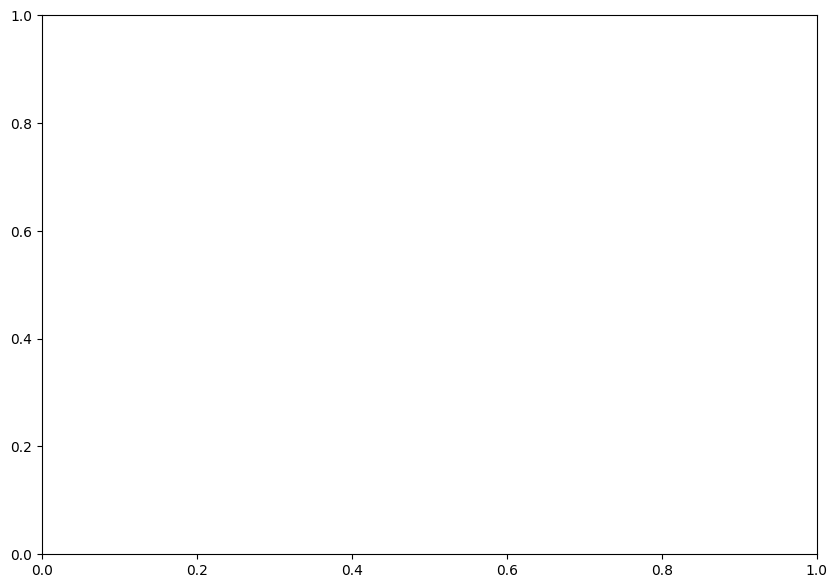

In [85]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#A21959")
ax.set_xlabel("Relative importance")
ax.set_title("XGBoost Feature Importance — Predicting Total Personal Income")
plt.tight_layout()
plt.show()

## 9. Save Model Artifacts

Save the trained model and feature column list to disk so the Streamlit app
can load them without re-running this notebook.

In [ ]:
import joblib
import json

# Save the model
joblib.dump(model, "model.pkl")

# Save the feature list so app.py knows what columns to send
with open("feature_columns.json", "w") as f:
    json.dump(features, f)

print("Saved model.pkl and feature_columns.json")
print(f"Model predicts log(income+1) — app must apply np.expm1() to output")
print(f"Trained on incomes ≤ $250K")
print(f"\nFeatures ({len(features)}):")
for f in features:
    print(f"  {f}")

Saved model.pkl and feature_columns.json
Model predicts log(income+1) — app must apply np.expm1() to output
Trained on incomes ≤ $250K

Features (20):
  AGE
  SEX
  RACE
  HISPAN
  MARST
  FAMSIZE
  NCHILD
  NCHLT5
  EDUC
  DEGFIELD
  OCC
  IND
  CLASSWKR
  UHRSWORK
  WKSWORK2
  PUMA
  FOREIGN_BORN
  CITIZEN
  SPEAKENG
  YRSUSA1


In [81]:
import pandas as pd
import numpy as np

# === SSS need: 2 adults + 2 kids in Montgomery County ===
df_sss = pd.read_excel("MD2023_SSS.xlsx", sheet_name="By Family")
df_sss.columns = df_sss.columns.str.strip()

kids_total = (df_sss["Infant(s)"] + df_sss["Preschooler(s)"] 
              + df_sss["Schoolager(s)"] + df_sss["Teenager(s)"])

moco_2a_2k = df_sss[
    (df_sss["County"] == "Montgomery County") &
    (df_sss["Adult(s)"] == 2) &
    (kids_total == 2)
]
print(f"Found {len(moco_2a_2k)} family configurations of 2 adults + 2 kids")
print("\nThe range across kid-age combinations:")
print(moco_2a_2k[["Family Type", "Annual Self-Sufficiency Wage"]].to_string())

sss_2023 = moco_2a_2k["Annual Self-Sufficiency Wage"].median()
sss_2026 = sss_2023 * 1.083
print(f"\nSSS median (2023 dollars): ${sss_2023:,.0f}")
print(f"SSS median (2026 dollars, CPI 1.083): ${sss_2026:,.0f}")

# === Actual income: 2-adult-2-kid households in Maryland ===
df_md = pd.read_csv("ipums_md_2023.csv")

# Filter to married couples with 2 children, family size 4
hh = df_md[
    (df_md["MARST"] == 1) &
    (df_md["NCHILD"] == 2) &
    (df_md["FAMSIZE"] == 4) &
    (df_md["FTOTINC"] >= 0) &
    (df_md["FTOTINC"] < 9999998)
].copy()

# One row per family (FTOTINC is duplicated across family members)
hh_unique = hh.drop_duplicates(subset=["SERIAL"])
print(f"\nFound {len(hh_unique)} unique 2-adult-2-kid households in MD")

income_2023 = hh_unique["FTOTINC"].median()
income_2026 = income_2023 * 1.125
print(f"Median family income (2023 dollars): ${income_2023:,.0f}")
print(f"Median family income (2026 dollars, ECI 1.125): ${income_2026:,.0f}")

# === The comparison ===
print(f"\n=== 2 adults + 2 kids in Montgomery County, 2026 dollars ===")
print(f"Needs:  ${sss_2026:,.0f}")
print(f"Earns:  ${income_2026:,.0f}  (median across MD families like this)")
print(f"Gap:    ${sss_2026 - income_2026:,.0f}")

Found 10 family configurations of 2 adults + 2 kids

The range across kid-age combinations:
      Family Type  Annual Self-Sufficiency Wage
10285  a2i2p0s0t0                     141336.06
10286  a2i1p1s0t0                     138316.70
10287  a2i1p0s1t0                     125961.91
10288  a2i1p0s0t1                     106272.42
10289  a2i0p2s0t0                     135297.35
10290  a2i0p1s1t0                     122942.56
10291  a2i0p1s0t1                     103689.39
10292  a2i0p0s2t0                     111536.06
10293  a2i0p0s1t1                      93119.97
10294  a2i0p0s0t2                      77493.53

SSS median (2023 dollars): $117,239
SSS median (2026 dollars, CPI 1.083): $126,970

Found 1966 unique 2-adult-2-kid households in MD
Median family income (2023 dollars): $181,800
Median family income (2026 dollars, ECI 1.125): $204,525

=== 2 adults + 2 kids in Montgomery County, 2026 dollars ===
Needs:  $126,970
Earns:  $204,525  (median across MD families like this)
Gap:    

In [ ]:
# Single parent + 2 kids in MoCo (SSS)
moco_1a_2k = df_sss[
    (df_sss["County"] == "Montgomery County") &
    (df_sss["Adult(s)"] == 1) &
    (kids_total == 2)
]
sss_2023 = moco_1a_2k["Annual Self-Sufficiency Wage"].median()
sss_2026 = sss_2023 * 1.083

# Single-parent households in MD (IPUMS)
hh = df_md[
    (df_md["MARST"].isin([4, 5, 6])) &  # divorced, separated, never married
    (df_md["NCHILD"] == 2) &
    (df_md["FAMSIZE"] == 3) &
    (df_md["FTOTINC"] >= 0) &
    (df_md["FTOTINC"] < 9999998)
].drop_duplicates(subset=["SERIAL"])

income_2023 = hh["FTOTINC"].median()
income_2026 = income_2023 * 1.125

print(f"Needs:  ${sss_2026:,.0f}")
print(f"Earns:  ${income_2026:,.0f}")
print(f"Gap:    ${sss_2026 - income_2026:,.0f}")

Needs:  $119,920
Earns:  $72,225
Gap:    $47,695


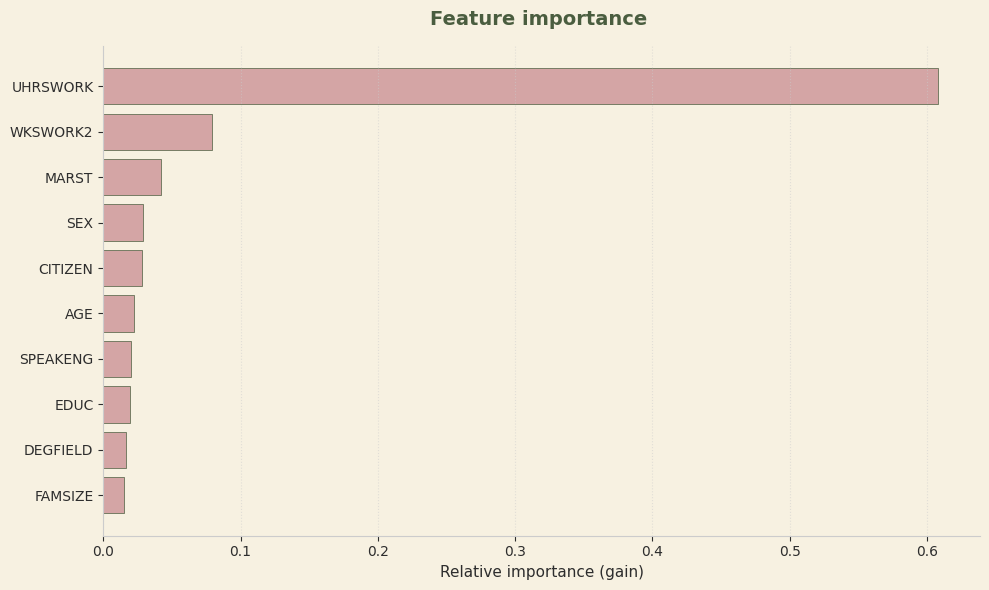

Saved: feature_importance_palette.png


In [87]:
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load saved model and features
model = joblib.load("model.pkl")
with open("feature_columns.json") as f:
    features = json.load(f)

# Rebuild importance dataframe
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Colors matching slide palette (sage + dusty pink, no blue)
SAGE_DARK = "#4A5D3F"
PINK = "#D4A5A5"
IVORY = "#F7F1E1"
TEXT = "#2D2D2D"

fig, ax = plt.subplots(figsize=(10, 6), facecolor=IVORY)
ax.set_facecolor(IVORY)

# Top 10 features, reversed so highest is on top
top10 = importance_df.head(10).iloc[::-1]
ax.barh(top10["feature"], top10["importance"], color=PINK, edgecolor=SAGE_DARK, linewidth=0.5)

ax.set_xlabel("Relative importance (gain)", fontsize=11, color=TEXT)
ax.set_title("Feature importance ", 
             fontsize=14, color=SAGE_DARK, fontweight="bold", pad=15)

# Clean up the look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors=TEXT)
ax.grid(axis="x", linestyle=":", color="#CCCCCC", alpha=0.5)

plt.tight_layout()
plt.savefig("feature_importance_palette.png", dpi=200, facecolor=IVORY, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_palette.png")